In [49]:
from pandas import concat, read_csv


df_train = read_csv("data/data_set_ALL_AML_train.csv").drop(columns=["Gene Description", "Gene Accession Number"])
df_test = read_csv("data/data_set_ALL_AML_independent.csv").drop(columns=["Gene Description", "Gene Accession Number"])
df_labels = read_csv("data/actual.csv")

In [50]:
import numpy as np
from pandas import DataFrame, merge, to_numeric


def prepare(df: DataFrame, labels: DataFrame) -> tuple[DataFrame, list[bool]]:
    df.reset_index(drop=True, inplace=True)
    df["patient"] = df.index.astype(str)
    labels["patient"] = labels["patient"].astype(str)
    df = merge(df, labels, on="patient", how="inner")
    df = df.drop(columns=["patient"])
    df = df[[isinstance(x, int) for x in df[0]]]
    y = df["cancer"]
    df = df.drop(columns=["cancer"])

    df_replaced = df.replace([np.inf, -np.inf], np.nan)
    means = df_replaced.mean()
    df = df.apply(lambda col: col.replace([np.inf, -np.inf], means[col.name]))

    y = [x=="AML" for x in y]

    return df, y

In [51]:
X_train, y_train = prepare(df_train.T, labels=df_labels)
X_test, y_test = prepare(df_test.T, labels=df_labels)

/var/folders/d3/48q8h80x3kv9x7jmp956v1j00000gn/T/ipykernel_45204/3580053770.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_replaced = df.replace([np.inf, -np.inf], np.nan)
/var/folders/d3/48q8h80x3kv9x7jmp956v1j00000gn/T/ipykernel_45204/3580053770.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.apply(lambda col: col.replace([np.inf, -np.inf], means[col.name]))
/var/folders/d3/48q8h80x3kv9x7jmp956v1j00000gn/T/ipykernel_45204/3580053770.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and w

In [52]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.tree import DecisionTreeClassifier 

dt = DecisionTreeClassifier()

dt.fit(X_train, y=y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
y_pred = dt.predict(X_test)

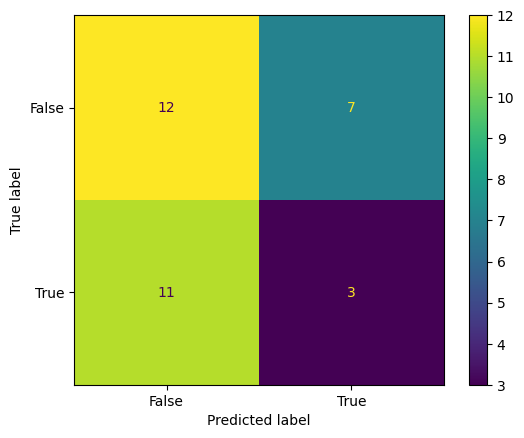

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


In [58]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

       False       0.52      0.63      0.57        19
        True       0.30      0.21      0.25        14

    accuracy                           0.45        33
   macro avg       0.41      0.42      0.41        33
weighted avg       0.43      0.45      0.44        33

ROC AUC: 0.4229323308270676
